# Next Observed — prediction associations

Find **correlations and associations in NOI forecasts** among indicators and partners.

Not clustering. Indicator grouping lives in `IndicatorClustering.ipynb`.

1. **Same IOC, other partner** — if predicted/active at A, what is the 7-day probability at B?
2. **IOC co-occurrence** — which indicators are forecast together at the same partner?
3. **Partner correlation** — which OpDivs have similar prediction profiles?

Latest production day under `OpDiv_Predictions`. Outputs: `htoc_ml/analysis/_outputs/next_observed_relationships/`


## Load today's NOI forecasts


In [3]:
import pandas as pd
from pathlib import Path
from datetime import date
from concurrent.futures import ThreadPoolExecutor, as_completed

from htoc.core.bootstrap import ensure_htoc_on_path
from htoc.core.eval.metrics import parse_probability_percent

ensure_htoc_on_path()

def load_one(path: Path) -> pd.DataFrame:
    return pd.read_csv(path).assign(Partner=path.parent.name)

main_folder = Path(r"Z:\HTOC\Data_Analytics\Data\OpDiv_Predictions")
allowed_folders = ["CDC", "CMS", "DHA", "FDA", "HHS", "HRSA", "IHS", "NIH", "OS", "VA"]
file_date = date.today().strftime("%Y%m%d")
paths = [
    main_folder / p / f"{p}_output_{file_date}.csv"
    for p in allowed_folders
    if (main_folder / p / f"{p}_output_{file_date}.csv").is_file()
]
if not paths:
    raise FileNotFoundError(f"No partner CSVs for {file_date} under {main_folder}")

frames = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, path): path for path in paths}
    for fut in as_completed(futures):
        frames.append(fut.result())

NOI_df = pd.concat(frames, ignore_index=True)
NOI_df = NOI_df.rename(columns={"ensemble_45d": "Probability: 45-Day"})
PROB_SRC = {
    "noi_prob_1": "Probability: 1-Day",
    "noi_prob_7": "Probability: 7-Day",
    "noi_prob_14": "Probability: 14-Day",
    "noi_prob_30": "Probability: 30-Day",
    "noi_prob_45": "Probability: 45-Day",
}
for col, src in PROB_SRC.items():
    if src in NOI_df.columns:
        NOI_df[col] = parse_probability_percent(NOI_df[src]) / 100.0

NOI_df["Indicator"] = NOI_df["Indicator"].astype("string").str.strip()
NOI_df["Partner"] = NOI_df["Partner"].astype("string").str.strip()
print(f"{len(paths)} partner files for {file_date}: {NOI_df.shape}")
NOI_df.head()


10 partner files for 20260903: (13198, 21)


,Indicator,Observed Today,Frequency (1d),Frequency (7d),Frequency (30d),Probability: 1-Day,Confidence: 1-Day,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,...,Probability: 30-Day,Confidence: 30-Day,Probability: 45-Day,Confidence: 45-Day,Partner,noi_prob_1,noi_prob_7,noi_prob_14,noi_prob_30,noi_prob_45
0,102.91.102.239,0,0.0,0.0,2.0,1.36%,1-Day: Low confidence,9.69%,7-Day: Low confidence,18.68%,...,68.25%,30-Day: Highly likely,49.66%,45-Day: Possibly active,CDC,0.0136,0.0969,0.1868,0.6825,0.4966
1,104.164.168.13,0,0.0,3.0,5.0,29.35%,1-Day: Low confidence,82.58%,7-Day: Highly likely,95.31%,...,99.71%,30-Day: Highly likely,74.93%,45-Day: Highly likely,CDC,0.2935,0.8258,0.9531,0.9971,0.7493
2,104.164.168.21,0,0.0,2.0,5.0,29.02%,1-Day: Low confidence,79.46%,7-Day: Highly likely,92.85%,...,99.58%,30-Day: Highly likely,74.92%,45-Day: Highly likely,CDC,0.2902,0.7946,0.9285,0.9958,0.7492
3,104.18.8.59,0,0.0,2.0,6.0,29.64%,1-Day: Low confidence,81.18%,7-Day: Highly likely,93.98%,...,99.69%,30-Day: Highly likely,74.98%,45-Day: Highly likely,CDC,0.2964,0.8118,0.9398,0.9969,0.7498
4,104.21.90.240,0,0.0,0.0,2.0,1.46%,1-Day: Low confidence,16.07%,7-Day: Low confidence,63.82%,...,82.86%,30-Day: Highly likely,65.62%,45-Day: Highly likely,CDC,0.0146,0.1607,0.6382,0.8286,0.6562


## Indicator × partner probability matrix


In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

noi = NOI_df.copy()
noi["active_7d"] = noi["Observed Today"].eq(1) | (noi["Frequency (7d)"].fillna(0) > 0)

prob_mat = (
    noi.pivot_table(index="Indicator", columns="Partner", values="noi_prob_7", aggfunc="max")
    .sort_index(axis=1)
)
active_mat = (
    noi.pivot_table(index="Indicator", columns="Partner", values="active_7d", aggfunc="max")
    .eq(True)
    .reindex(columns=prob_mat.columns)
)
print(f"probability matrix {prob_mat.shape[0]} indicators × {prob_mat.shape[1]} partners")
if prob_mat.shape[1] < len(allowed_folders):
    missing = sorted(set(allowed_folders) - set(prob_mat.columns))
    print(f"missing partner files today: {missing}")
display(prob_mat.describe().round(3))


probability matrix 5167 indicators × 9 partners


C:\Users\jaskew\AppData\Local\Temp\ipykernel_31328\3753093293.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


Partner,CDC,CMS,DHA,FDA,HHS,HRSA,IHS,NIH,OS
count,165.000,1035.000,411.000,409.000,1350.000,3331.000,918.000,2525.000,1121.000
mean,0.434,0.708,0.150,0.660,0.403,0.380,0.488,0.500,0.558
std,0.378,0.403,0.314,0.428,0.461,0.425,0.416,0.432,0.448
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.066,0.218,0.000,0.111,0.000,0.000,0.056,0.001,0.044
50%,0.273,0.998,0.001,0.993,0.002,0.115,0.598,0.635,0.775
75%,0.779,1.000,0.065,1.000,0.995,0.890,0.929,0.972,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## Partner–partner correlation

Each partner is a vector of 7-day probabilities over the same indicators.
High correlation means those OpDivs get similar NOI scores for the same IOCs.


Partner,CDC,CMS,DHA,FDA,HHS,HRSA,IHS,NIH,OS
Partner,,,,,,,,,
CDC,1.000,0.398,NaN,0.149,0.371,0.215,0.462,0.455,0.241
CMS,0.398,1.000,-0.058,0.930,0.377,0.855,0.586,0.340,0.731
DHA,NaN,-0.058,1.000,-0.303,0.308,-0.066,0.080,0.347,0.196
FDA,0.149,0.930,-0.303,1.000,0.460,0.757,0.583,0.724,0.671
HHS,0.371,0.377,0.308,0.460,1.000,0.704,0.326,-0.055,0.810
HRSA,0.215,0.855,-0.066,0.757,0.704,1.000,0.579,0.419,0.774
IHS,0.462,0.586,0.080,0.583,0.326,0.579,1.000,0.302,0.526
NIH,0.455,0.340,0.347,0.724,-0.055,0.419,0.302,1.000,0.454
OS,0.241,0.731,0.196,0.671,0.810,0.774,0.526,0.454,1.000


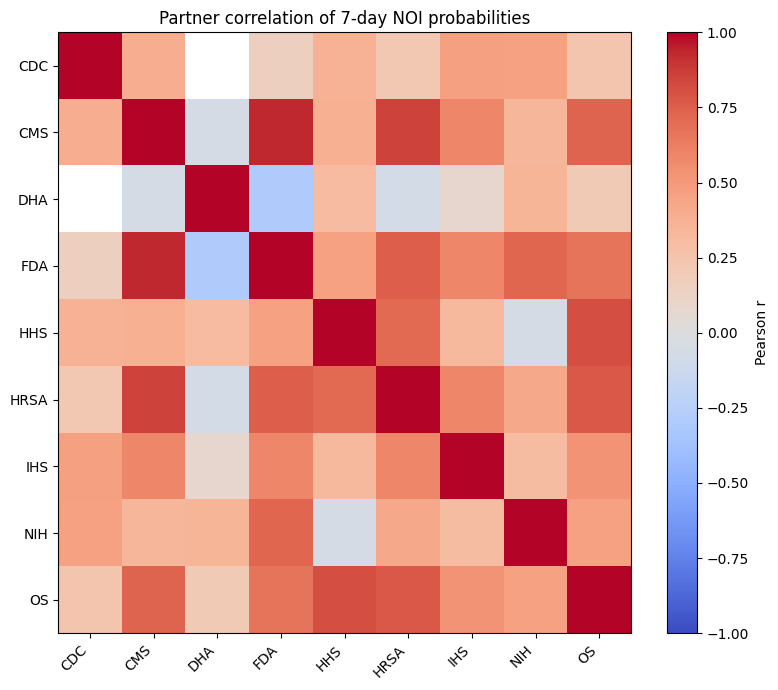

In [5]:
partner_corr = prob_mat.corr(min_periods=30)
display(partner_corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(partner_corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
labs = list(partner_corr.columns)
ax.set_xticks(range(len(labs)))
ax.set_yticks(range(len(labs)))
ax.set_xticklabels(labs, rotation=45, ha="right")
ax.set_yticklabels(labs)
ax.set_title("Partner correlation of 7-day NOI probabilities")
fig.colorbar(im, ax=ax, label="Pearson r")
fig.tight_layout()
plt.show()
plt.close(fig)


## Same indicator: active at source → probability at target

Next-observed pattern: IOC is **active** at source (seen today or freq_7 > 0) and we look at
the forecast probability at every other partner. High mean `target_noi_prob_7` is the
association "seen at A, likely next at B."


4,062 directed pairs (active at source, not at target)


,source,target,n,mean_target_noi
3,CDC,HHS,8,0.337
36,HHS,OS,15,0.265
32,HHS,FDA,4,0.251
30,HHS,CMS,37,0.214
52,IHS,OS,19,0.208
33,HHS,HRSA,47,0.205
65,OS,HHS,51,0.197
62,OS,CMS,64,0.194
66,OS,HRSA,86,0.187
64,OS,FDA,10,0.183


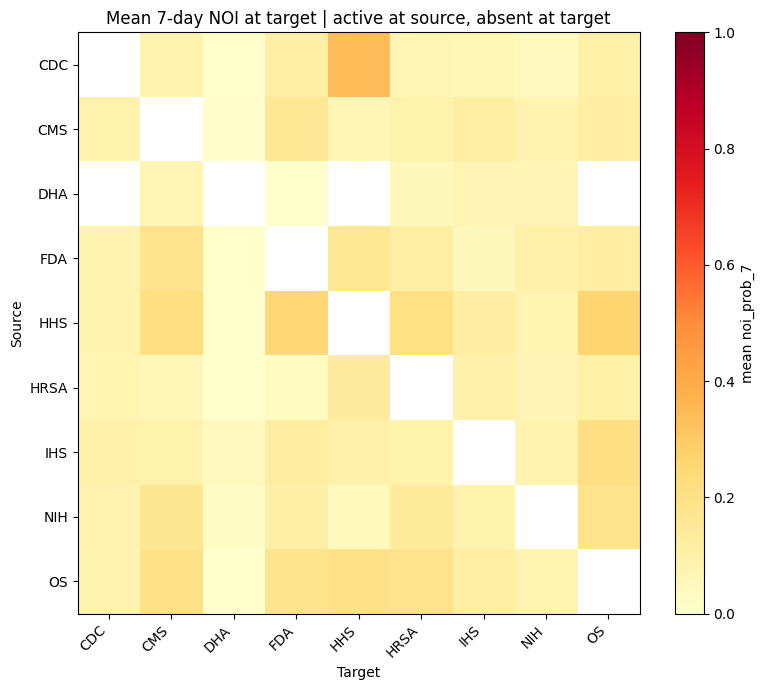

In [6]:
HORIZON_DAYS = 7
rows = []
partners = list(prob_mat.columns)
for indicator, row in active_mat.iterrows():
    sources = [p for p in partners if bool(row.get(p, False))]
    if not sources:
        continue
    probs = prob_mat.loc[indicator]
    for source in sources:
        for target in partners:
            if target == source:
                continue
            if bool(row.get(target, False)):
                continue
            val = probs.get(target)
            if pd.isna(val):
                continue
            rows.append(
                {
                    "indicator": indicator,
                    "source": source,
                    "target": target,
                    "target_noi_prob_7": float(val),
                    "horizon_days": HORIZON_DAYS,
                }
            )

spread = pd.DataFrame(rows)
print(f"{len(spread):,} directed pairs (active at source, not at target)")

pair_assoc = (
    spread.groupby(["source", "target"], as_index=False)
    .agg(n=("indicator", "size"), mean_target_noi=("target_noi_prob_7", "mean"))
    .sort_values(["mean_target_noi", "n"], ascending=False)
)
display(pair_assoc.head(20).round(3))

heat = pair_assoc.pivot(index="source", columns="target", values="mean_target_noi")
heat = heat.reindex(index=partners, columns=partners)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(heat.to_numpy(float), cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(partners)))
ax.set_yticks(range(len(partners)))
ax.set_xticklabels(partners, rotation=45, ha="right")
ax.set_yticklabels(partners)
ax.set_xlabel("Target")
ax.set_ylabel("Source")
ax.set_title("Mean 7-day NOI at target | active at source, absent at target")
fig.colorbar(im, ax=ax, label="mean noi_prob_7")
fig.tight_layout()
plt.show()
plt.close(fig)


## Indicator co-occurrence at the same partner

Among IOCs **active** at a partner, which pairs appear together?
Lift > 1 means they co-occur more often than independently.
Restricted to indicators active at 2+ partners so rare one-offs do not dominate.


In [7]:
from itertools import combinations

active_inds = active_mat.index[active_mat.sum(axis=1) >= 2]
am = active_mat.loc[active_inds]
n_partners = am.shape[1]
support = am.sum(axis=1) / n_partners

pair_rows = []
for partner in am.columns:
    present = am.index[am[partner]].tolist()
    if len(present) < 2:
        continue
    for a, b in combinations(present, 2):
        pair_rows.append((a, b) if a < b else (b, a))

co = pd.Series(pair_rows).value_counts()
assoc = pd.DataFrame(
    [(a, b, n) for (a, b), n in co.items()],
    columns=["indicator_a", "indicator_b", "n_partners_together"],
)
assoc["support_a"] = assoc["indicator_a"].map(support)
assoc["support_b"] = assoc["indicator_b"].map(support)
assoc["lift"] = assoc["n_partners_together"] / n_partners / (
    assoc["support_a"] * assoc["support_b"]
)
assoc = assoc.sort_values(["lift", "n_partners_together"], ascending=False)
print(f"{len(assoc):,} co-occurring indicator pairs")
display(assoc.head(20).round(3))


435,067 co-occurring indicator pairs


,indicator_a,indicator_b,n_partners_together,support_a,support_b,lift
198487,64.62.156.196,93.115.7.238,2,0.222,0.222,4.5
198497,64.62.156.196,91.196.152.92,2,0.222,0.222,4.5
198533,64.62.156.20,64.62.156.55,2,0.222,0.222,4.5
198534,64.62.156.20,64.62.156.65,2,0.222,0.222,4.5
198535,64.62.156.20,64.62.156.67,2,0.222,0.222,4.5
198539,64.62.156.20,64.62.156.75,2,0.222,0.222,4.5
198540,64.62.156.20,64.62.156.223,2,0.222,0.222,4.5
198542,64.62.156.20,64.62.156.229,2,0.222,0.222,4.5
198543,64.62.156.20,64.62.156.23,2,0.222,0.222,4.5
198544,64.62.156.20,64.62.156.25,2,0.222,0.222,4.5


## Indicator–indicator correlation (shared partner profile)

Pearson correlation of 7-day probability vectors across partners, for IOCs present
at 3+ partners. High r means two indicators get similar NOI scores at the same OpDivs.


Indicator,205.210.31.42,205.210.31.57,205.210.31.254,205.210.31.64,205.210.31.143,205.210.31.111,205.210.31.252,205.210.31.159,205.210.31.192,205.210.31.231
Indicator,,,,,,,,,,
205.210.31.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205.210.31.192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


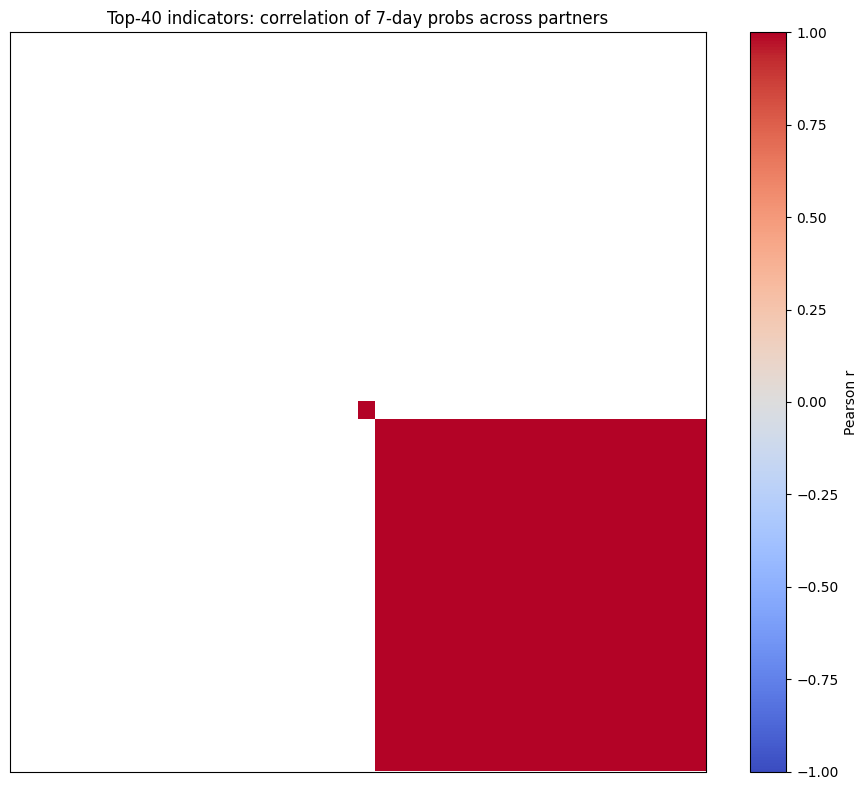

ValueError: cannot insert Indicator, already exists

In [9]:
wide = prob_mat.loc[active_mat.sum(axis=1) >= 3]
# cap size so the corr matrix stays readable
top = (
    wide.mean(axis=1)
    .sort_values(ascending=False)
    .head(40)
    .index
)
ind_corr = wide.loc[top].T.corr(min_periods=3)
display(ind_corr.round(2).iloc[:10, :10])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(ind_corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_title("Top-40 indicators: correlation of 7-day probs across partners")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, label="Pearson r")
fig.tight_layout()
plt.show()
plt.close(fig)

# strongest associated pairs
corr_pairs = (
    ind_corr.where(np.triu(np.ones(ind_corr.shape), k=1).astype(bool))
    .stack()
    .rename("r")
    .reset_index()
)
corr_pairs.columns = ["indicator_a", "indicator_b", "r"]
display(corr_pairs.sort_values("r", ascending=False).head(15).round(3))


## Save
